# 🚗 Road Crash Fatality Prediction: ML for Transport Safety Policy

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **ATSB** — Road crash investigation, safety analytics
- **Dept of Infrastructure** — National Road Safety Strategy 2021-2030
- **ABS** — Motor vehicle census, crash statistics
- **State road authorities** — Speed cameras, black spot programs

Dataset: seaborn built-in car_crashes — NO dataset needed. 51 rows, 8 features.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
df=sns.load_dataset('car_crashes')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i}. {col:20s} | {str(df[col].dtype):10s} | uniq={df[col].nunique()}")
df.head()

Loaded: 51 x 8
  0. total                | float64    | uniq=45
  1. speeding             | float64    | uniq=50
  2. alcohol              | float64    | uniq=50
  3. not_distracted       | float64    | uniq=50
  4. no_previous          | float64    | uniq=50
  5. ins_premium          | float64    | uniq=51
  6. ins_losses           | float64    | uniq=51
  7. abbrev               | object     | uniq=51


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## 2. Target

Target: 'total' (total crashes per billion miles)
count    51.000000
mean     15.790196
std       4.122002
min       5.900000
25%      12.750000
50%      15.600000
75%      18.500000
max      23.900000
Name: total, dtype: float64


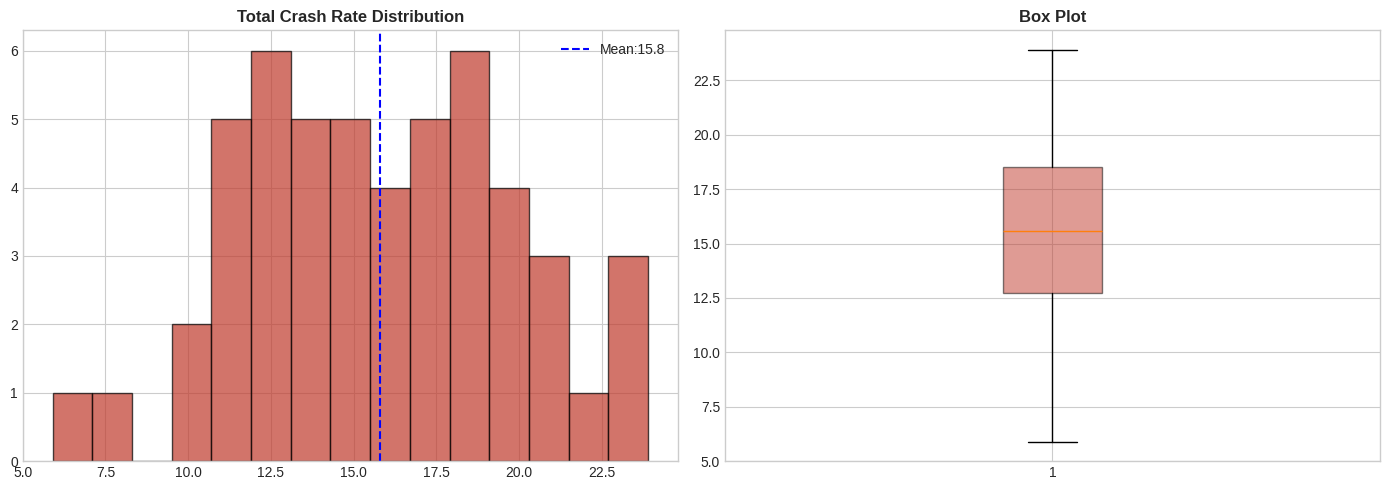

AU: ~1,200 road deaths/year. National Road Safety Strategy targets zero fatalities.


In [2]:
tc='total'
print(f"Target: '{tc}' (total crashes per billion miles)");print(df[tc].describe())
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=15,color='#c0392b',edgecolor='black',alpha=0.7)
axes[0].set_title('Total Crash Rate Distribution',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='blue',ls='--',label=f'Mean:{df[tc].mean():.1f}')
axes[0].legend()
axes[1].boxplot(df[tc],patch_artist=True,boxprops=dict(facecolor='#c0392b',alpha=0.5))
axes[1].set_title('Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ~1,200 road deaths/year. National Road Safety Strategy targets zero fatalities.")

## 3. EDA

Numeric: ['speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses']


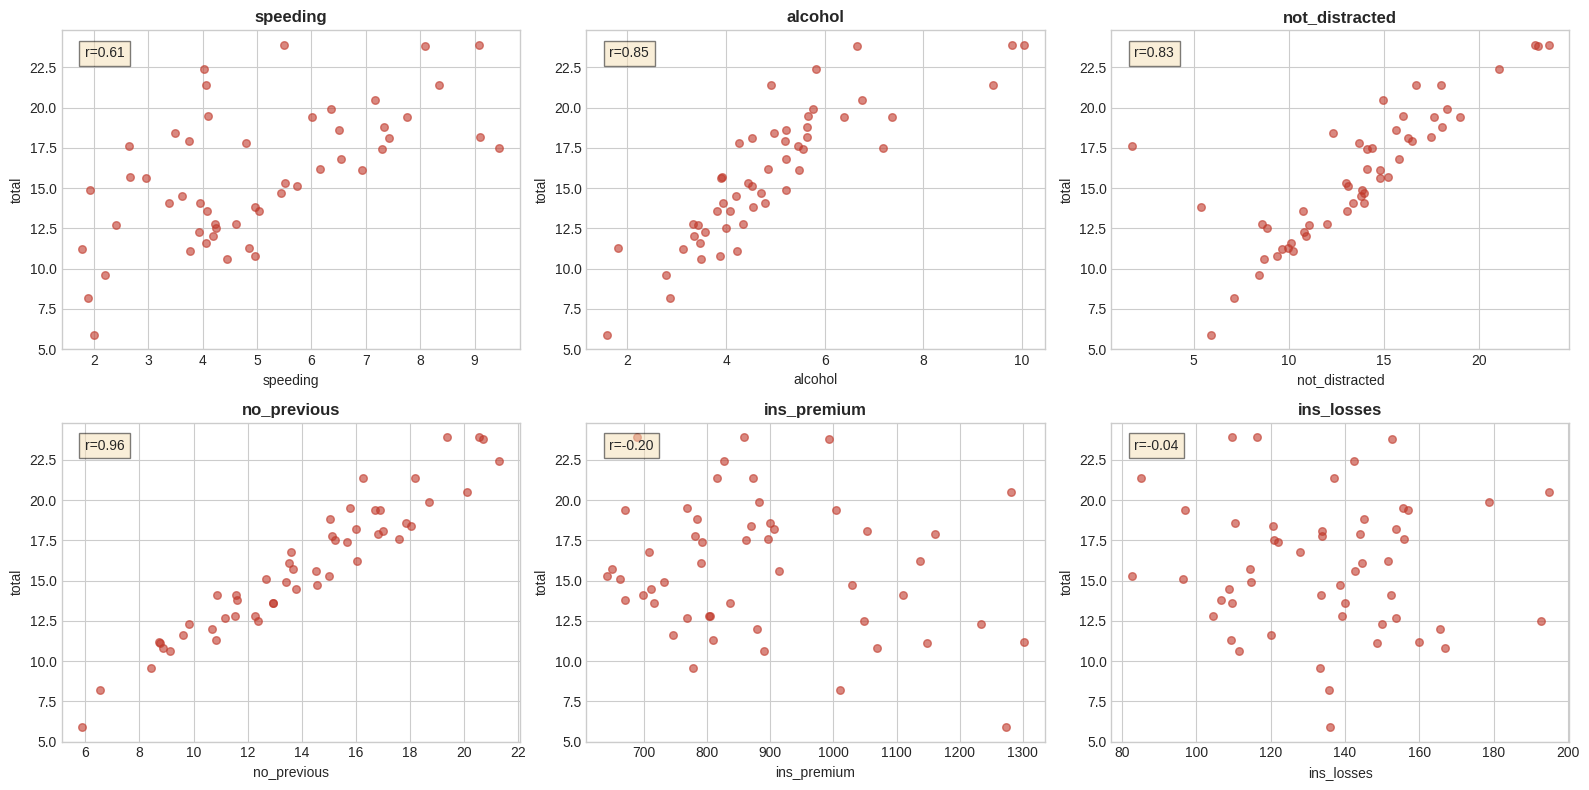

In [3]:
nums=[c2 for c2 in df.select_dtypes(include=[np.number]).columns if c2!=tc]
print(f"Numeric: {nums}")
fig,axes=plt.subplots(2,3,figsize=(16,8));axes=axes.flatten()
for i,col in enumerate(nums[:6]):
    axes[i].scatter(df[col],df[tc],alpha=0.6,s=30,color='#c0392b')
    axes[i].set_xlabel(col);axes[i].set_ylabel('total')
    axes[i].set_title(col,fontweight='bold')
    r=df[[col,tc]].corr().iloc[0,1]
    axes[i].text(0.05,0.95,f'r={r:.2f}',transform=axes[i].transAxes,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

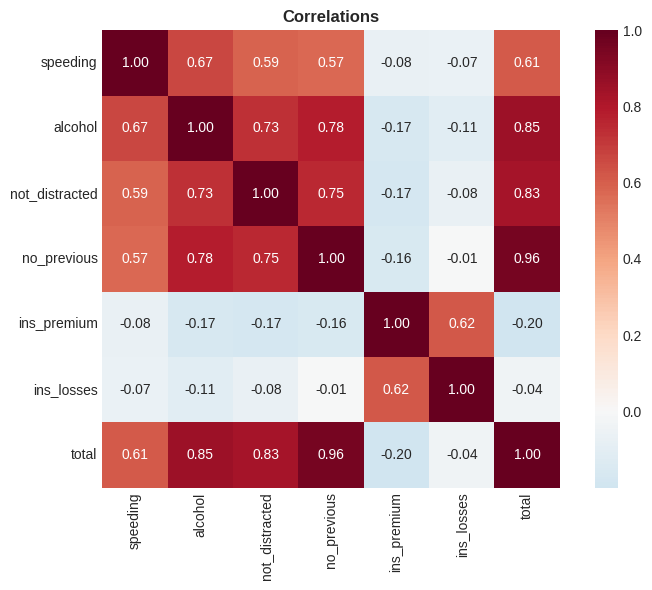

In [4]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4-5. Training

In [5]:
# Drop abbrev (state name)
X=df[nums].copy();y=df[tc].values
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s);print(f"  Fold{fi+1}: RMSE={r:.2f} MAE={m3:.2f} R2={s:.4f}")
    el=time.time()-t0;results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.2f} R2={np.mean(f2):.4f}")


Ridge
  Fold1: RMSE=1.47 MAE=1.04 R2=0.9072
  Fold2: RMSE=1.03 MAE=0.85 R2=0.9208
  Fold3: RMSE=0.89 MAE=0.71 R2=0.9346
  AVG: RMSE=1.13 R2=0.9208

RF
  Fold1: RMSE=1.48 MAE=1.08 R2=0.9063
  Fold2: RMSE=1.22 MAE=0.97 R2=0.8901
  Fold3: RMSE=1.02 MAE=0.82 R2=0.9137
  AVG: RMSE=1.24 R2=0.9034

XGB
  Fold1: RMSE=1.72 MAE=1.35 R2=0.8734
  Fold2: RMSE=1.74 MAE=1.39 R2=0.7740
  Fold3: RMSE=1.28 MAE=1.02 R2=0.8654
  AVG: RMSE=1.58 R2=0.8376

LGBM
  Fold1: RMSE=4.88 MAE=4.33 R2=-0.0215
  Fold2: RMSE=3.88 MAE=2.98 R2=-0.1161
  Fold3: RMSE=3.52 MAE=2.91 R2=-0.0242
  AVG: RMSE=4.09 R2=-0.0539


## 6. Comparison & Residuals

COMPARISON
Model RMSE  MAE      R2
Ridge 1.13 0.86  0.9208
   RF 1.24 0.96  0.9034
  XGB 1.58 1.25  0.8376
 LGBM 4.09 3.41 -0.0539

Best: Ridge


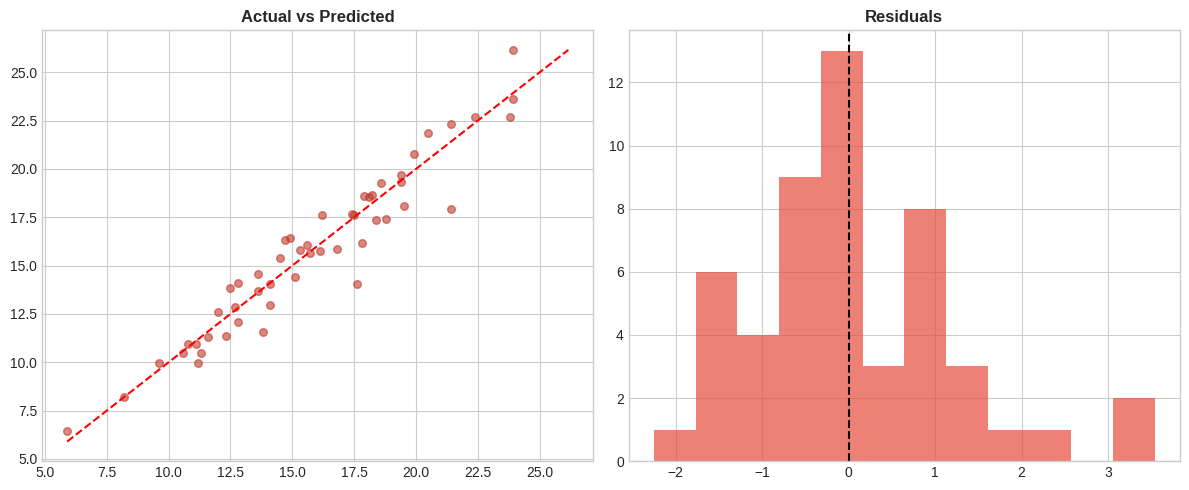

In [6]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.2f}",'MAE':f"{v['mae']:.2f}",'R2':f"{v['r2']:.4f}",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2']].to_string(index=False));print(f"\nBest: {best}")
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(y,bp,alpha=0.6,s=30,color='#c0392b');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=12,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 7. Deployment

In [7]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  R2: {br['r2']:.4f}  MAE: {br['mae']:.2f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y)}")
checks={'R2>0.30':br['r2']>0.30,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")
print("\nArchitecture: State road authority data -> Fabric -> black spot identification, speed policy")

DEPLOYMENT READINESS
  Model: Ridge  R2: 0.9208  MAE: 0.86
  Feats: 6  Rows: 51
  [pass] R2>0.30
  [pass] CV
  APPROVED

Architecture: State road authority data -> Fabric -> black spot identification, speed policy
